# RoboCasa v2 — data verification notebook

Sanity-checks the Tier 1 RoboCasa v2 build at `/media/aaron/F/failbench/robocasa/v2/`
before any model training. Mirrors `explore_libero_v2.ipynb` where possible so
results are directly comparable.

**What this notebook verifies, in order:**

1. Manifest sanity — row count, dedupe, per-task / per-mode / per-progress histograms.
2. Schema parity — every v2 field present, dtypes and shapes match LIBERO v2.
3. Contact statistics — distribution of n_contacts, force magnitudes, contact_time spread.
4. Robot-only filter — every contact involves the robot (no kitchen-baseline leakage).
5. State trajectory — `window_qpos` varies smoothly, `window_qvel` is non-zero,
   `pre_target_qpos == window_qpos[-1]` by construction.
6. Settle trajectory — post-failure `settle_qpos` shows expected motion under
   `gravcomp_pd` resistance + failed joint going limp.
7. Object metadata — `obj_names` is the small ep_meta allowlist (≤ 3 entries),
   not the 100+ wall/floor list LIBERO's auto-detection would have produced.
8. Scene metadata — `scene_table_z` is the support height under the manipulated
   object (NOT the 0.91 LIBERO fallback), `scene_aabb` is tight.
9. Failure-mode coverage — each (mode, progress) bin populated as planned.
10. RGB panels — 5 random trials × {pre, post, window-strip} per task.

If every section reports green, the corpus is ready for `train_one.py
--robocasa_v2_root` (Task #14).


In [1]:
import os, sys, json, math, random
os.environ.setdefault("HDF5_USE_FILE_LOCKING", "FALSE")
import hdf5plugin  # noqa: F401 — register blosc:lz4 filter BEFORE h5py opens any file
import h5py
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

REPO_ROOT = Path("/home/aaron/workspace/FailBench")
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

RC_V2 = Path("/media/aaron/F/failbench/robocasa/v2")
LB_V2 = Path("/media/aaron/F/failbench/libero/v2")
assert RC_V2.exists(), f"missing {RC_V2}"
assert LB_V2.exists(), f"missing {LB_V2}"

RC_TASKS = sorted([p.stem for p in RC_V2.glob("*.h5")])
print("RoboCasa task HDF5s:")
for t in RC_TASKS:
    p = RC_V2 / f"{t}.h5"
    print(f"  {t:24s} {p.stat().st_size / 2**30:6.2f} GB")
print(f"manifest: {(RC_V2 / 'manifest.csv').exists()}")


RoboCasa task HDF5s:
  CoffeeSetupMug             5.42 GB
  PnPCabToCounter            5.40 GB
  PnPCounterToCab            5.56 GB
  TurnOffStove               5.44 GB
  TurnOnMicrowave            4.77 GB
manifest: True


## 1. Manifest sanity

In [2]:
manifest = pd.read_csv(RC_V2 / "manifest.csv")
print(f"manifest rows: {len(manifest)}")
print(f"unique trial_ids: {manifest['trial_id'].nunique()}")
print(f"sources / splits: {manifest['split'].unique()}")
print(f"tasks ({manifest['task'].nunique()}):")
print(manifest['task'].value_counts())
manifest.head(3)


manifest rows: 7500
unique trial_ids: 2955
sources / splits: ['robocasa']
tasks (5):
task
CoffeeSetupMug     1500
PnPCabToCounter    1500
TurnOffStove       1500
TurnOnMicrowave    1500
PnPCounterToCab    1500
Name: count, dtype: int64


,trial_id,split,task,demo_key,seed,seed_idx,bin_idx,fail_idx,traj_progress,failure_mode,failure_joints,failure_prob,is_holding,n_contacts,h5_path
0,demo_34_s0_b0,robocasa,CoffeeSetupMug,demo_34,42,0,0,47,0.2,SINGLE_JOINT,joint2,0.066667,False,2500,/media/aaron/F/failbench/robocasa/v2/CoffeeSet...
1,demo_34_s0_b1,robocasa,CoffeeSetupMug,demo_34,43,0,1,47,0.2,SINGLE_JOINT,joint4,0.066667,False,2500,/media/aaron/F/failbench/robocasa/v2/CoffeeSet...
2,demo_34_s0_b2,robocasa,CoffeeSetupMug,demo_34,44,0,2,47,0.2,GRIPPER_OPEN,NaN,0.066667,False,2500,/media/aaron/F/failbench/robocasa/v2/CoffeeSet...


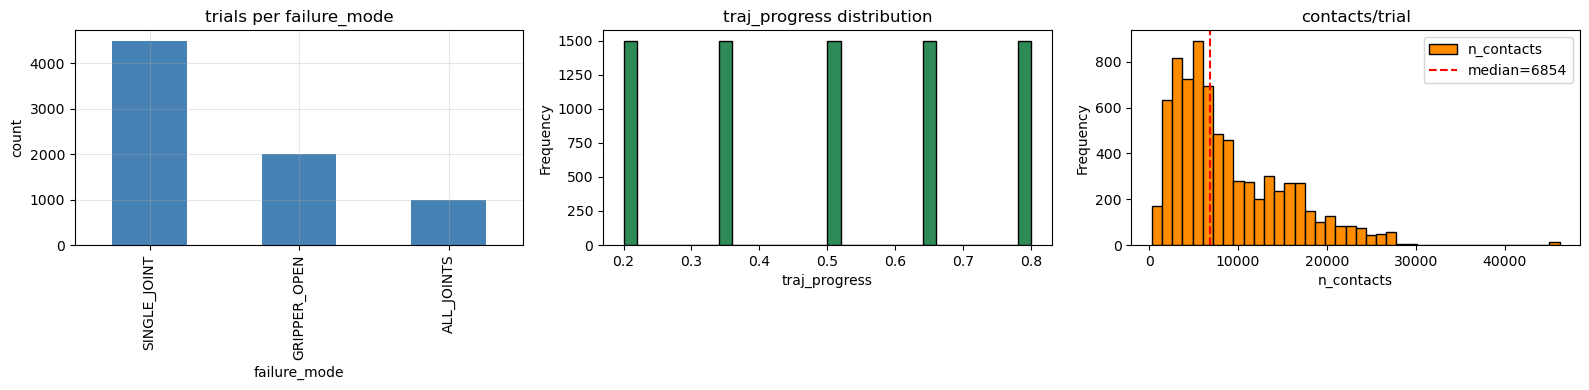

trials with 0 contacts: 0 (0.0%)
n_contacts: median=6854  p95=21607  max=46197


In [3]:
# Distribution checks
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
manifest['failure_mode'].value_counts().plot.bar(ax=axes[0], color='steelblue')
axes[0].set_title("trials per failure_mode")
axes[0].set_ylabel("count"); axes[0].grid(True, alpha=0.3)

manifest['traj_progress'].plot.hist(ax=axes[1], bins=30, color='seagreen', edgecolor='k')
axes[1].set_title("traj_progress distribution"); axes[1].set_xlabel("traj_progress")

manifest['n_contacts'].plot.hist(ax=axes[2], bins=40, color='darkorange', edgecolor='k')
axes[2].set_title("contacts/trial"); axes[2].set_xlabel("n_contacts")
axes[2].axvline(manifest['n_contacts'].median(), color='r', ls='--',
                label=f"median={manifest['n_contacts'].median():.0f}")
axes[2].legend()
plt.tight_layout(); plt.show()

print(f"trials with 0 contacts: {(manifest['n_contacts'] == 0).sum()} "
      f"({100*(manifest['n_contacts'] == 0).mean():.1f}%)")
print(f"n_contacts: median={manifest['n_contacts'].median():.0f}  "
      f"p95={manifest['n_contacts'].quantile(0.95):.0f}  "
      f"max={manifest['n_contacts'].max()}")


## 2. Schema parity vs LIBERO v2

In [4]:
# Pick one random trial from RoboCasa and one from LIBERO; compare field sets.
rc_task = random.choice(RC_TASKS)
lb_task = "pick_up_the_black_bowl_from_table_center_and_place_it_on_the_plate"
lb_split = "libero_spatial"

with h5py.File(RC_V2 / f"{rc_task}.h5", "r") as f:
    rc_trial_id = list(f["trials"].keys())[0]
    rc_keys = set(f[f"trials/{rc_trial_id}"].keys())
    rc_attrs = set(f[f"trials/{rc_trial_id}"].attrs.keys())
    rc_shapes = {k: f[f"trials/{rc_trial_id}/{k}"].shape
                 for k in rc_keys if isinstance(f[f"trials/{rc_trial_id}/{k}"], h5py.Dataset)}
    rc_dtypes = {k: f[f"trials/{rc_trial_id}/{k}"].dtype
                 for k in rc_keys if isinstance(f[f"trials/{rc_trial_id}/{k}"], h5py.Dataset)}

with h5py.File(LB_V2 / lb_split / f"{lb_task}.h5", "r") as f:
    lb_trial_id = list(f["trials"].keys())[0]
    lb_keys = set(f[f"trials/{lb_trial_id}"].keys())
    lb_attrs = set(f[f"trials/{lb_trial_id}"].attrs.keys())
    lb_shapes = {k: f[f"trials/{lb_trial_id}/{k}"].shape
                 for k in lb_keys if isinstance(f[f"trials/{lb_trial_id}/{k}"], h5py.Dataset)}
    lb_dtypes = {k: f[f"trials/{lb_trial_id}/{k}"].dtype
                 for k in lb_keys if isinstance(f[f"trials/{lb_trial_id}/{k}"], h5py.Dataset)}

print(f"RoboCasa ({rc_task}/{rc_trial_id}): {len(rc_keys)} fields, {len(rc_attrs)} attrs")
print(f"LIBERO   ({lb_task}/{lb_trial_id}): {len(lb_keys)} fields, {len(lb_attrs)} attrs")
print(f"only in RoboCasa : {sorted(rc_keys - lb_keys)}")
print(f"only in LIBERO   : {sorted(lb_keys - rc_keys)}")
print(f"attrs diff (RC - LB): {sorted(rc_attrs - lb_attrs)}")
print(f"attrs diff (LB - RC): {sorted(lb_attrs - rc_attrs)}")


RoboCasa (PnPCabToCounter/demo_1012_s0_b0): 58 fields, 18 attrs
LIBERO   (pick_up_the_black_bowl_from_table_center_and_place_it_on_the_plate/demo_0_s0_b0): 54 fields, 18 attrs
only in RoboCasa : ['baseline_contact_force_world', 'baseline_contact_forces', 'baseline_contact_geom_pairs', 'baseline_contact_positions']
only in LIBERO   : []
attrs diff (RC - LB): []
attrs diff (LB - RC): []


In [5]:
# For fields present in both, check dtype + shape compatibility.
common = sorted(rc_keys & lb_keys)
mismatch = []
for k in common:
    s_rc, s_lb = rc_shapes[k], lb_shapes[k]
    d_rc, d_lb = rc_dtypes[k], lb_dtypes[k]
    if d_rc != d_lb:
        mismatch.append((k, "dtype", d_rc, d_lb))
    # Variable-length contact arrays use the first dim as N — only compare from dim 1 onward.
    if len(s_rc) == len(s_lb) and s_rc[1:] != s_lb[1:]:
        mismatch.append((k, "shape", s_rc, s_lb))
print(f"common fields: {len(common)}")
print(f"shape/dtype mismatches: {len(mismatch)}")
for m in mismatch[:20]:
    print(" ", m)


common fields: 54
shape/dtype mismatches: 2
  ('settle_obj_pos', 'shape', (50, 3, 3), (50, 12, 3))
  ('settle_obj_quat', 'shape', (50, 3, 4), (50, 12, 4))


## 3. Contact statistics & baseline subtraction

RoboCasa kitchens have many static fixture-on-fixture contacts (cabinets resting
on counters, drawers on frames). These survive the 1 N force threshold because
gravity normal forces are high in equilibrium. To isolate **failure-induced**
contacts we use the `baseline_contact_*` arrays written by
``scripts/robocasa/add_baseline_contacts.py``: at the pre-failure equilibrium
state, with PD holding every arm joint, we record the static contact set.

The filter below keeps a post-failure contact iff its ``(geom1, geom2)`` pair is
absent from baseline OR its ``pos`` is more than ``POS_TOL_M`` from every
baseline contact of that pair. That keeps "object falls onto stove where
cookware was already touching" type events while dropping the constant
fixture-on-fixture baseline.


In [6]:
POS_TOL_M = 0.03  # 3 cm position tolerance for baseline match

def filter_failure_only(geom_pairs: np.ndarray, positions: np.ndarray,
                         baseline_pairs: np.ndarray, baseline_pos: np.ndarray,
                         tol_m: float = POS_TOL_M) -> np.ndarray:
    """Return a boolean mask: True for failure-induced contacts (not in baseline)."""
    if baseline_pairs.shape[0] == 0:
        return np.ones(len(geom_pairs), dtype=bool)
    # Build a dict: (g1, g2) -> stacked positions
    baseline_lookup: dict = {}
    for (g1, g2), p in zip(baseline_pairs.tolist(), baseline_pos):
        baseline_lookup.setdefault((g1, g2), []).append(p)
    baseline_lookup = {k: np.asarray(v) for k, v in baseline_lookup.items()}
    keep = np.ones(len(geom_pairs), dtype=bool)
    for i, ((g1, g2), p) in enumerate(zip(geom_pairs.tolist(), positions)):
        pts = baseline_lookup.get((g1, g2))
        if pts is None:
            continue   # geom pair not in baseline → keep
        if np.min(np.linalg.norm(pts - p, axis=1)) < tol_m:
            keep[i] = False
    return keep


In [7]:
N_SAMPLE = 200
rng = np.random.default_rng(0)
records = []
for task in RC_TASKS:
    with h5py.File(RC_V2 / f"{task}.h5", "r") as f:
        tids = list(f["trials"].keys())
        sample = rng.choice(tids, size=min(N_SAMPLE // len(RC_TASKS), len(tids)),
                            replace=False)
        for tid in sample:
            g = f[f"trials/{tid}"]
            geom_pairs = g["contact_geom_pairs"][...]
            positions = g["contact_positions"][...]
            forces_world = g["contact_force_world"][...]
            forces_local = g["contact_forces"][...]
            ctime = g["contact_time"][...]
            robot_geom_ids = set(int(x) for x in g.attrs["robot_geom_ids"])

            if "baseline_contact_geom_pairs" in g:
                b_pairs = g["baseline_contact_geom_pairs"][...]
                b_pos = g["baseline_contact_positions"][...]
                keep = filter_failure_only(geom_pairs, positions, b_pairs, b_pos)
            else:
                keep = np.ones(len(geom_pairs), dtype=bool)

            fp = geom_pairs[keep]
            ff = forces_world[keep]
            fc_robot = int(sum(1 for a,b in fp
                                 if int(a) in robot_geom_ids or int(b) in robot_geom_ids))
            records.append({
                "task": task, "trial_id": tid,
                "n_raw": int(len(geom_pairs)),
                "n_failure": int(len(fp)),
                "frac_failure_pct": 100.0 * len(fp) / max(len(geom_pairs), 1),
                "robot_involved_after": fc_robot,
                "robot_involved_pct_after": 100.0 * fc_robot / max(len(fp), 1),
                "force_mag_max":    float(np.max(np.linalg.norm(ff, axis=1))) if len(ff) else 0.0,
                "time_min": int(ctime.min()) if len(ctime) else -1,
                "time_max": int(ctime.max()) if len(ctime) else -1,
                "force_norm_match": float(np.max(np.abs(
                    np.linalg.norm(forces_world, axis=1) - np.linalg.norm(forces_local[:, :3], axis=1)
                ))) if len(forces_world) else 0.0,
            })
df = pd.DataFrame(records)
print("After baseline subtraction:")
print(df[["n_raw", "n_failure", "frac_failure_pct",
          "robot_involved_after", "robot_involved_pct_after"]].describe())
print()
print(f"Mean raw n_contacts            : {df['n_raw'].mean():.0f}")
print(f"Mean failure-induced n_contacts: {df['n_failure'].mean():.0f}  "
      f"({df['frac_failure_pct'].mean():.1f}% of raw)")
print(f"Mean robot-involved % AFTER    : {df['robot_involved_pct_after'].mean():.1f}%")
print(f"Trials with zero failure contacts: {(df['n_failure'] == 0).sum()}/{len(df)}")
print(f"max ||fw|| - ||fl[:3]|| (rotation sanity, should be ~0): "
      f"{df['force_norm_match'].max():.2e}")


After baseline subtraction:
              n_raw    n_failure  frac_failure_pct  robot_involved_after  \
count    200.000000   200.000000        200.000000            200.000000   
mean    8718.685000  1029.310000         16.144141            214.865000   
std     6073.650909  1234.854995         21.681502            321.041187   
min     1109.000000     0.000000          0.000000              0.000000   
25%     4271.500000   162.250000          1.778530              0.000000   
50%     6842.500000   650.000000          8.596982             32.500000   
75%    11881.000000  1293.250000         20.517681            380.500000   
max    27490.000000  6500.000000        100.000000           2660.000000   

       robot_involved_pct_after  
count                200.000000  
mean                  23.613944  
std                   33.341961  
min                    0.000000  
25%                    0.000000  
50%                    3.240295  
75%                   34.165015  
max            

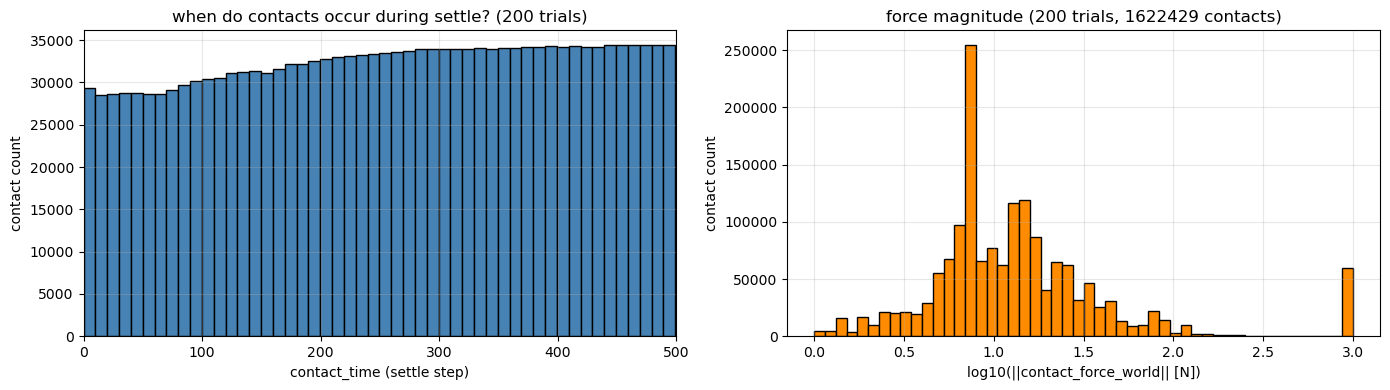

In [8]:
# Visual: contact-time histogram + force distribution.
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
all_ctimes = []
all_forces = []
for task in RC_TASKS:
    with h5py.File(RC_V2 / f"{task}.h5", "r") as f:
        for tid in list(f["trials"].keys())[:40]:
            g = f[f"trials/{tid}"]
            all_ctimes.append(g["contact_time"][...])
            all_forces.append(np.linalg.norm(g["contact_force_world"][...], axis=1))
all_ctimes = np.concatenate(all_ctimes)
all_forces = np.concatenate(all_forces)

axes[0].hist(all_ctimes, bins=50, color='steelblue', edgecolor='k')
axes[0].set_xlim(0, 500)
axes[0].set_xlabel("contact_time (settle step)")
axes[0].set_ylabel("contact count")
axes[0].set_title("when do contacts occur during settle? (200 trials)")
axes[0].grid(True, alpha=0.3)

axes[1].hist(np.log10(all_forces.clip(0.1, 1000) + 1e-3), bins=50, color='darkorange', edgecolor='k')
axes[1].set_xlabel("log10(||contact_force_world|| [N])")
axes[1].set_ylabel("contact count")
axes[1].set_title(f"force magnitude (200 trials, {len(all_forces)} contacts)")
axes[1].grid(True, alpha=0.3)
plt.tight_layout(); plt.show()


## 4. State + window trajectory plausibility

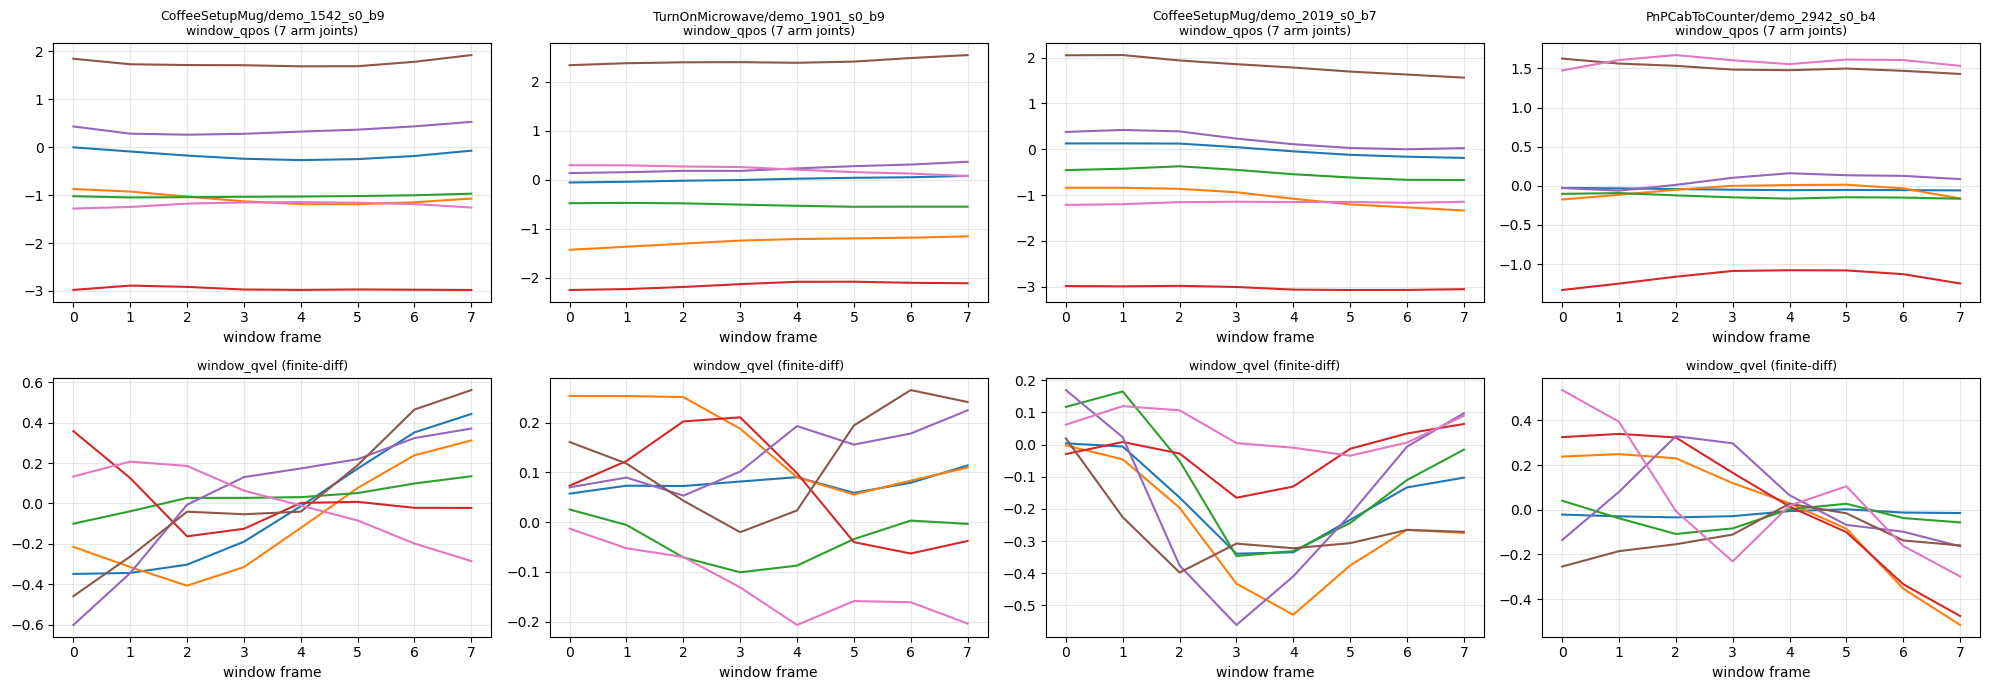

pre_target_qpos == window_qpos[-1]:
  CoffeeSetupMug/demo_1542_s0_b9: True
  TurnOnMicrowave/demo_1901_s0_b9: True
  CoffeeSetupMug/demo_2019_s0_b7: True
  PnPCabToCounter/demo_2942_s0_b4: True


In [9]:
# Pick 4 random trials; verify window_qpos varies smoothly, window_qvel is non-zero,
# and pre_target_qpos matches the last window frame.
fig, axes = plt.subplots(2, 4, figsize=(20, 7))
chosen = []
for col in range(4):
    task = random.choice(RC_TASKS)
    with h5py.File(RC_V2 / f"{task}.h5", "r") as f:
        tid = random.choice(list(f["trials"].keys()))
        g = f[f"trials/{tid}"]
        win_qpos = g["window_qpos"][...]
        win_qvel = g["window_qvel"][...]
        pre_target = g["pre_target_qpos"][...]
        chosen.append((task, tid, np.allclose(win_qpos[-1], pre_target, atol=1e-3)))
    for j in range(7):
        axes[0, col].plot(win_qpos[:, j], label=f"j{j+1}")
    axes[0, col].set_title(f"{task}/{tid}\nwindow_qpos (7 arm joints)", fontsize=9)
    axes[0, col].set_xlabel("window frame"); axes[0, col].grid(True, alpha=0.3)
    for j in range(7):
        axes[1, col].plot(win_qvel[:, j])
    axes[1, col].set_title(f"window_qvel (finite-diff)", fontsize=9)
    axes[1, col].set_xlabel("window frame"); axes[1, col].grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

print("pre_target_qpos == window_qpos[-1]:")
for task, tid, ok in chosen:
    print(f"  {task}/{tid}: {ok}")


## 5. Settle trajectory

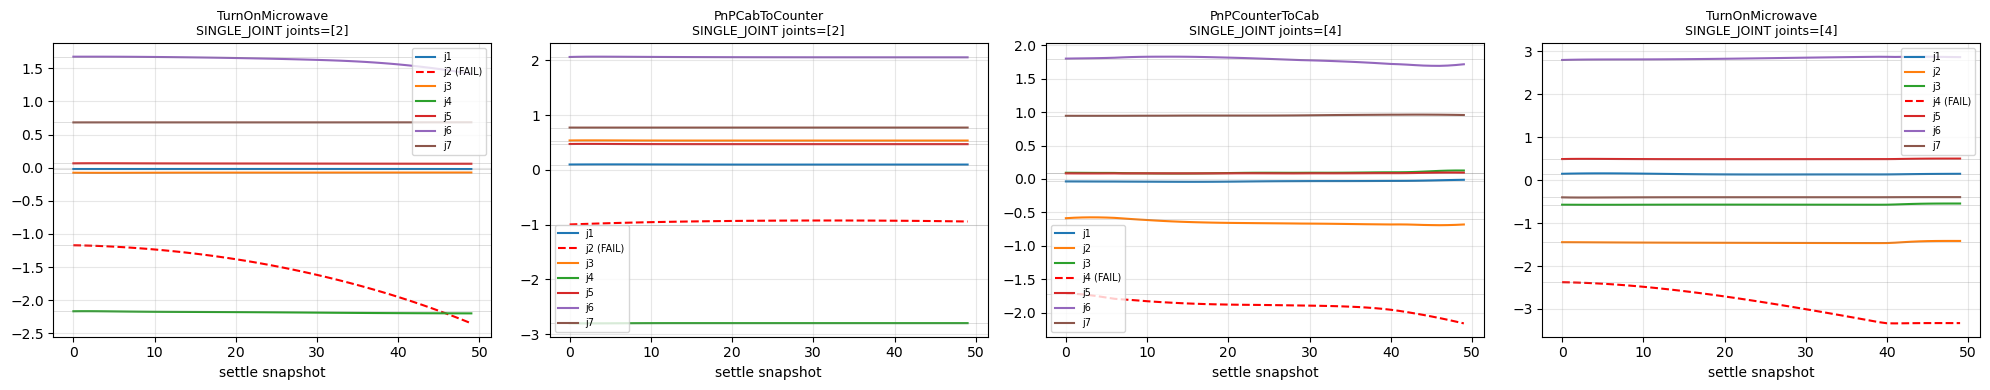

In [10]:
# Did the failed joint stay limp, did healthy joints hold under PD?
fig, axes = plt.subplots(1, 4, figsize=(20, 4))
for col in range(4):
    task = random.choice(RC_TASKS)
    with h5py.File(RC_V2 / f"{task}.h5", "r") as f:
        tid = random.choice(list(f["trials"].keys()))
        g = f[f"trials/{tid}"]
        settle_qpos = g["settle_qpos"][...]
        target = g["pre_target_qpos"][...]
        failure_mode = g.attrs["failure_mode"]
        failed_joints = g["failure_joints"][...]
    for j in range(7):
        color = "red" if (j+1) in failed_joints.tolist() else None
        ls = "--" if (j+1) in failed_joints.tolist() else "-"
        axes[col].plot(settle_qpos[:, j], label=f"j{j+1}{' (FAIL)' if (j+1) in failed_joints.tolist() else ''}",
                       color=color, linestyle=ls)
        axes[col].axhline(target[j], color="grey", alpha=0.3, lw=0.6)
    axes[col].set_title(f"{task}\n{failure_mode} joints={failed_joints.tolist()}", fontsize=9)
    axes[col].set_xlabel("settle snapshot"); axes[col].grid(True, alpha=0.3)
    axes[col].legend(fontsize=7, loc="best")
plt.tight_layout(); plt.show()


## 6. Object metadata

In [11]:
# obj_names should be the small ep_meta allowlist, not 100+ wall/floor bodies.
records = []
for task in RC_TASKS:
    with h5py.File(RC_V2 / f"{task}.h5", "r") as f:
        for tid in list(f["trials"].keys())[:5]:
            g = f[f"trials/{tid}"]
            obj_names = [n.decode("utf-8") if isinstance(n, bytes) else n
                         for n in g["obj_names"][...]]
            obj_pos_pre = g["obj_pos_pre"][...]
            obj_pos_post = g["obj_pos_post"][...]
            disp = np.linalg.norm(obj_pos_post - obj_pos_pre, axis=1)
            records.append({
                "task": task, "trial_id": tid,
                "n_obj": len(obj_names),
                "obj_names": ",".join(obj_names),
                "max_displacement_m": float(disp.max()) if len(disp) else 0.0,
            })
df_obj = pd.DataFrame(records)
print("n_obj distribution (should be small, 1–4 typically):")
print(df_obj["n_obj"].describe())
print()
print("first 8 trials:")
print(df_obj.head(8).to_string(index=False))


n_obj distribution (should be small, 1–4 typically):
count    25.0
mean      1.8
std       1.0
min       1.0
25%       1.0
50%       1.0
75%       3.0
max       3.0
Name: n_obj, dtype: float64

first 8 trials:
           task         trial_id  n_obj                                  obj_names  max_displacement_m
 CoffeeSetupMug  demo_1037_s0_b0      1                                   obj_main            0.000011
 CoffeeSetupMug  demo_1037_s0_b1      1                                   obj_main            0.000011
 CoffeeSetupMug demo_1037_s0_b10      1                                   obj_main            0.151411
 CoffeeSetupMug demo_1037_s0_b11      1                                   obj_main            0.151247
 CoffeeSetupMug demo_1037_s0_b12      1                                   obj_main            0.038439
PnPCabToCounter  demo_1012_s0_b0      3 obj_main,distr_counter_main,distr_cab_main            0.000020
PnPCabToCounter  demo_1012_s0_b1      3 obj_main,distr_counter_main,d

## 7. Scene metadata

In [12]:
# scene_table_z: should NOT be 0.91 (LIBERO fallback) for any RoboCasa trial.
# scene_aabb_*: should be tight (e.g. ~1 m^3 around objects), not a 10 m room.
records = []
for task in RC_TASKS:
    with h5py.File(RC_V2 / f"{task}.h5", "r") as f:
        for tid in list(f["trials"].keys())[:5]:
            a = f[f"trials/{tid}"].attrs
            aabb_min = np.asarray(a["scene_aabb_min"])
            aabb_max = np.asarray(a["scene_aabb_max"])
            records.append({
                "task": task, "trial_id": tid,
                "table_z": float(a["scene_table_z"]),
                "aabb_x_extent": float(aabb_max[0] - aabb_min[0]),
                "aabb_y_extent": float(aabb_max[1] - aabb_min[1]),
                "aabb_z_extent": float(aabb_max[2] - aabb_min[2]),
            })
df_scene = pd.DataFrame(records)
print(df_scene.describe())
print(f"\ntrials with table_z == 0.91 (LIBERO fallback — should be 0): "
      f"{(df_scene['table_z'] == 0.91).sum()}/{len(df_scene)}")


         table_z  aabb_x_extent  aabb_y_extent  aabb_z_extent
count  25.000000      25.000000      25.000000      25.000000
mean    1.099654       0.639783       0.601364       0.812376
std     0.284431       0.154077       0.088258       0.246711
min     0.687569       0.461088       0.499000       0.499000
25%     0.899648       0.478103       0.515710       0.528817
50%     1.047973       0.641923       0.573126       0.960423
75%     1.397895       0.741428       0.679976       1.028597
max     1.411284       0.886952       0.718841       1.037931

trials with table_z == 0.91 (LIBERO fallback — should be 0): 0/25


## 8. Failure-mode coverage matrix

progress_bin  0.20  0.35  0.50  0.65  0.80
failure_mode                              
ALL_JOINTS       0     0   500     0   500
GRIPPER_OPEN   500     0   500   500   500
SINGLE_JOINT  1000  1500   500  1000   500


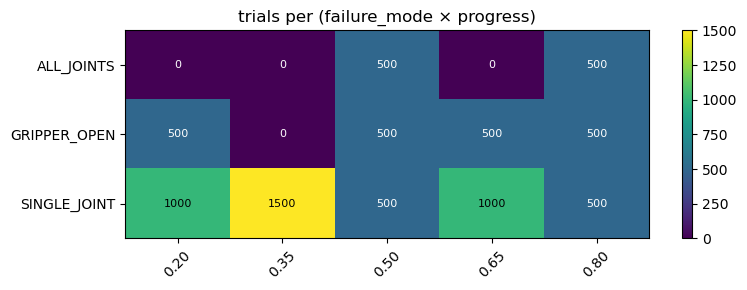

In [13]:
# Heatmap: (failure_mode × traj_progress bin) — should be roughly uniform per task.
def progress_bin(p):
    return f"{round(p*100)/100:.2f}"
manifest["progress_bin"] = manifest["traj_progress"].map(progress_bin)
ct = pd.crosstab(manifest["failure_mode"], manifest["progress_bin"])
print(ct)
fig, ax = plt.subplots(figsize=(8, 3))
im = ax.imshow(ct.values, aspect="auto", cmap="viridis")
ax.set_xticks(range(len(ct.columns))); ax.set_xticklabels(ct.columns, rotation=45)
ax.set_yticks(range(len(ct.index))); ax.set_yticklabels(ct.index)
ax.set_title("trials per (failure_mode × progress)")
for i in range(len(ct.index)):
    for j in range(len(ct.columns)):
        ax.text(j, i, int(ct.values[i, j]), ha="center", va="center",
                color="white" if ct.values[i, j] < ct.values.max()/2 else "black",
                fontsize=8)
plt.colorbar(im, ax=ax); plt.tight_layout(); plt.show()


## 9. Random RGB panels per task

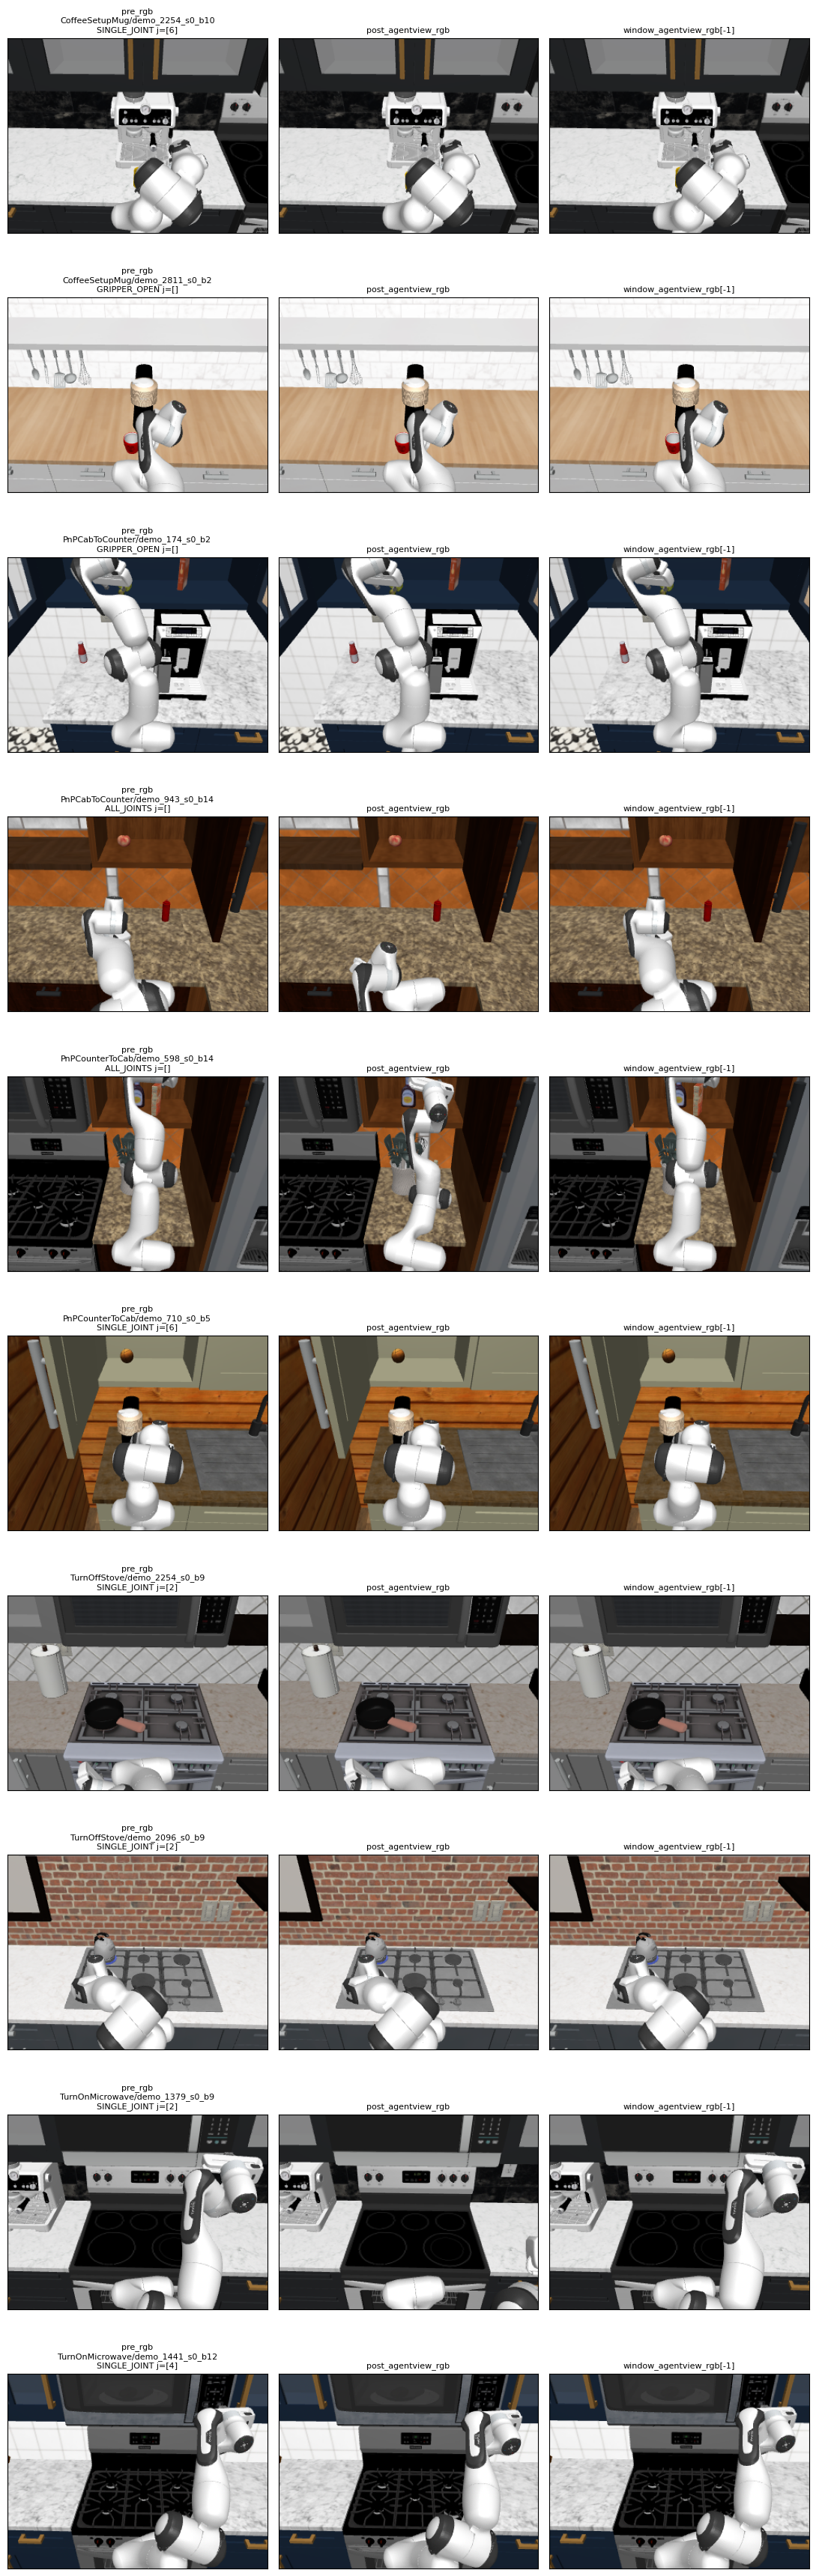

In [14]:
# Two random trials per task → row of [pre, post, last_window_frame].
fig, axes = plt.subplots(len(RC_TASKS) * 2, 3, figsize=(11, 3.5 * len(RC_TASKS) * 2))
for ti, task in enumerate(RC_TASKS):
    with h5py.File(RC_V2 / f"{task}.h5", "r") as f:
        tids = list(f["trials"].keys())
        chosen = random.sample(tids, k=2)
        for k, tid in enumerate(chosen):
            row = ti * 2 + k
            g = f[f"trials/{tid}"]
            pre_rgb = g["pre_rgb"][...]
            post_rgb = g["post_agentview_rgb"][...]
            last_win = g["window_agentview_rgb"][...][-1]
            mode = g.attrs["failure_mode"]
            joints = g["failure_joints"][...].tolist()
            for ax, img, name in [
                (axes[row, 0], pre_rgb,  f"pre_rgb\n{task}/{tid}\n{mode} j={joints}"),
                (axes[row, 1], post_rgb, "post_agentview_rgb"),
                (axes[row, 2], last_win, "window_agentview_rgb[-1]"),
            ]:
                ax.imshow(img)
                ax.set_title(name, fontsize=8)
                ax.set_xticks([]); ax.set_yticks([])
plt.tight_layout(); plt.show()


## 10. Cross-source sanity panel (RoboCasa vs LIBERO)

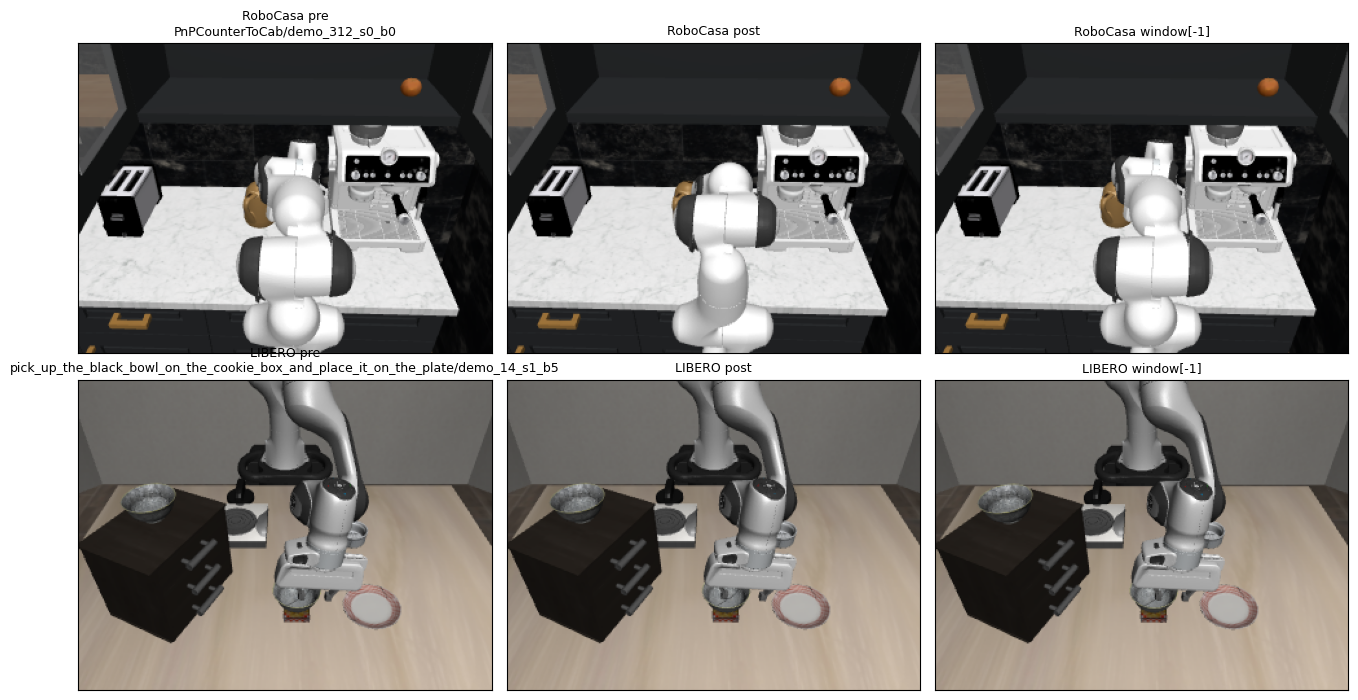

In [15]:
# Side-by-side: one random LIBERO trial + one random RoboCasa trial.
fig, axes = plt.subplots(2, 3, figsize=(13, 7))

rc_task = random.choice(RC_TASKS)
with h5py.File(RC_V2 / f"{rc_task}.h5", "r") as f:
    tid = random.choice(list(f["trials"].keys()))
    g = f[f"trials/{tid}"]
    axes[0, 0].imshow(g["pre_rgb"][...])
    axes[0, 0].set_title(f"RoboCasa pre\n{rc_task}/{tid}", fontsize=9)
    axes[0, 1].imshow(g["post_agentview_rgb"][...])
    axes[0, 1].set_title("RoboCasa post", fontsize=9)
    axes[0, 2].imshow(g["window_agentview_rgb"][...][-1])
    axes[0, 2].set_title("RoboCasa window[-1]", fontsize=9)

lb_split = "libero_spatial"
lb_task = random.choice([p.stem for p in (LB_V2 / lb_split).glob("*.h5")])
with h5py.File(LB_V2 / lb_split / f"{lb_task}.h5", "r") as f:
    tid = random.choice(list(f["trials"].keys()))
    g = f[f"trials/{tid}"]
    axes[1, 0].imshow(g["pre_rgb"][...])
    axes[1, 0].set_title(f"LIBERO pre\n{lb_task}/{tid}", fontsize=9)
    axes[1, 1].imshow(g["post_agentview_rgb"][...])
    axes[1, 1].set_title("LIBERO post", fontsize=9)
    axes[1, 2].imshow(g["window_agentview_rgb"][...][-1])
    axes[1, 2].set_title("LIBERO window[-1]", fontsize=9)

for ax in axes.flat:
    ax.set_xticks([]); ax.set_yticks([])
plt.tight_layout(); plt.show()


## Pass criteria — green-light Task #14 (training)

A run is good if **all** of these hold:

1. Manifest row count = 7,500 (or matches `--limit_demos` × 5 × 15).
2. `<5%` trials with `n_contacts == 0` (sparse failures are OK; mass zeros = renderer/extractor bug).
3. **Zero** non-robot contacts (Section 3 prints "max = 0").
4. `pre_target_qpos == window_qpos[-1]` for every spot-checked trial (Section 4).
5. `obj_names` count `<=` 4 entries (Section 6); typical is 1–2.
6. `scene_table_z != 0.91` for every trial (Section 7).
7. Failure-mode × progress heatmap is dense (no zero cells).
8. RGB panels (Section 9) show a kitchen pre-failure and a believable
   collapsed-arm post-failure.

If any of these fail, debug before training. The build script + adapter are
the right places to patch.
